In [1]:
import numpy as np, pandas as pd
import torch
import matplotlib.pyplot as plt, seaborn as sns
import matplotlib as mpl
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.datasets import load_wine, fetch_openml
import pandas as pd
from drd import DRD# stored in base

/user/bnc2119/.local/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


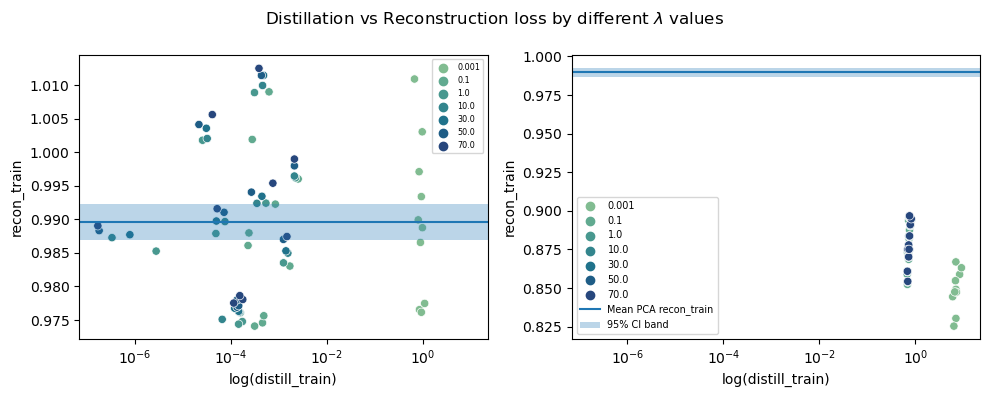

In [28]:
# plotting 
fig, axes = plt.subplots(1, 2, figsize=(10,4), sharex = True)
df_single_cell = pd.read_csv('results/single_cell_umap_drd_joint_p_0.5p_0.1p.csv')
df_single_cell = df_single_cell[df_single_cell.teacher_method != "pca"]
df_single_cell = df_single_cell[df_single_cell.student_method == "drd"].copy()
metrics = ["distill_test", "recon_test", "distill_train", "recon_train"]
sns.scatterplot(data = df_single_cell, x = 'distill_train', y = 'recon_train', marker='o', hue='lambda_d', ax = axes[0], palette=sns.color_palette("crest", 7))
axes[0].set_xscale('log')
axes[0].set_xlabel('log(distill_train)')
axes[0].legend(fontsize='xx-small')

sc_pca_recon_vals = df_single_cell.loc[df_single_cell.student_method == "drd", "recon_train"]
sc_pca_mean = sc_pca_recon_vals.mean()
sem = sc_pca_recon_vals.std(ddof=1) / np.sqrt(len(sc_pca_recon_vals))
ci = 1.96 * sem
axes[0].axhline(sc_pca_mean, label='Mean PCA recon_train')
axes[0].axhspan(sc_pca_mean - ci, sc_pca_mean + ci, alpha=0.3, label='95% CI band')

df_mnist = pd.read_csv('results/mnist_umap_drd_joint_p_0.5p_0.1p.csv')
df_mnist = df_mnist[df_mnist.teacher_method != "pca"]
df_mnist = df_mnist[df_mnist.student_method == "drd"].copy()
sns.scatterplot(data = df_mnist, x = 'distill_train', y = 'recon_train', marker='o', hue='lambda_d', ax = axes[1], palette=sns.color_palette("crest", 7))
plt.xscale('log')
axes[1].set_xlabel('log(distill_train)')
axes[1].legend(fontsize='xx-small')

mn_pca_recon_vals = df_single_cell.loc[df_single_cell.student_method == "drd", "recon_train"]
mn_pca_mean = mn_pca_recon_vals.mean()
sem = mn_pca_recon_vals.std(ddof=1) / np.sqrt(len(mn_pca_recon_vals))
ci = 1.96 * sem
axes[1].axhline(mn_pca_mean, label='Mean PCA recon_train')
axes[1].axhspan(mn_pca_mean - ci, mn_pca_mean + ci, alpha=0.3, label='95% CI band')
axes[1].legend(fontsize='x-small')

plt.suptitle("Distillation vs Reconstruction loss by different $\lambda$ values")
plt.tight_layout()

In [2]:
def plot_pca_recon(df, ax, type):
    pca_recon_vals = df.loc[df.student_method == "drd", f"recon_{type}"]
    pca_mean = pca_recon_vals.mean()
    sem = pca_recon_vals.std(ddof=1) / np.sqrt(len(pca_recon_vals))
    ci = 1.96 * sem
    ax.axhline(pca_mean, label=f'Mean PCA recon_{type}')
    ax.axhspan(pca_mean - ci, pca_mean + ci, alpha=0.3, label='95% CI band')
    return ax

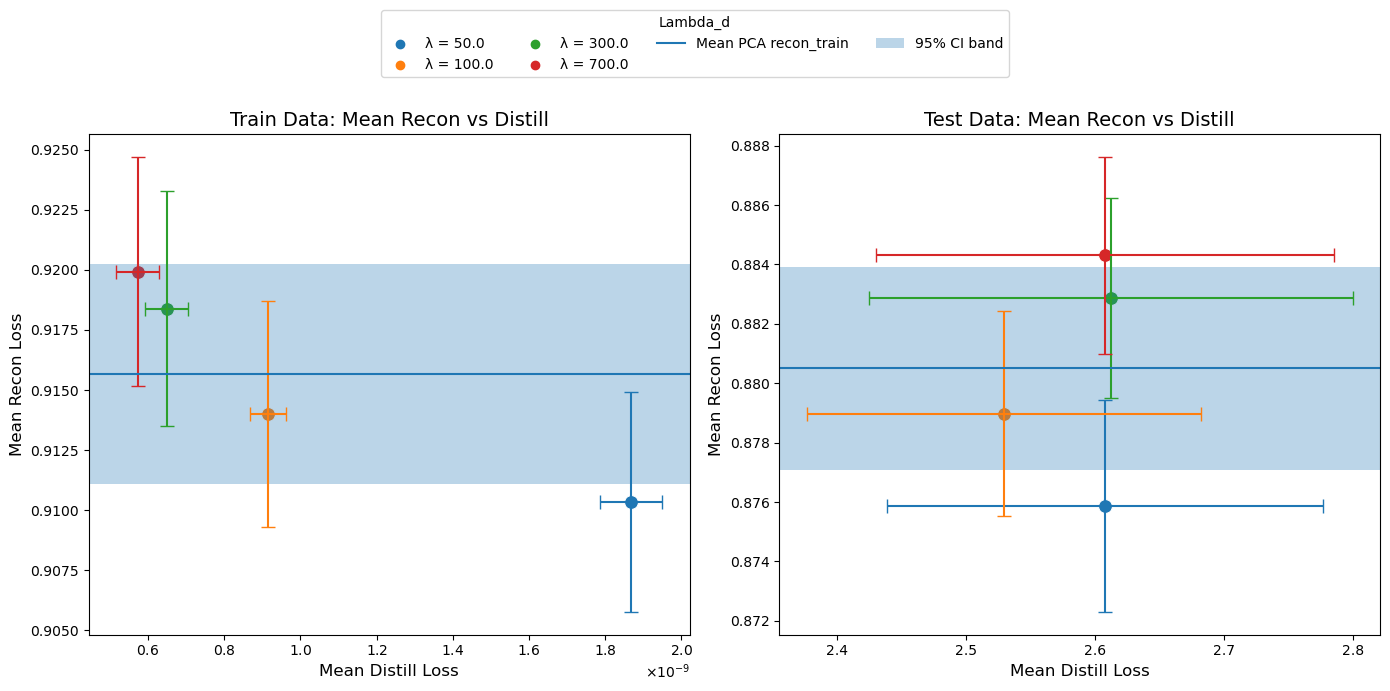

In [ ]:
df_single_cell = pd.read_csv('results/single_cell_pca_drd_joint_n=801_v3.csv')
df_single_cell = df_single_cell[df_single_cell.student_method == "drd"]
# Prepare the figure with two subplots: train and test
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False, sharey=False)

for idx, split in enumerate(['train', 'test']):
    ax = axes[idx]
    
    # Compute mean and SEM across seeds for each lambda_d
    grouped = df_single_cell.groupby('lambda_d').agg(
        mean_distill=('distill_' + split, 'mean'),
        sem_distill=(f'distill_{split}', 'sem'),
        mean_recon=('recon_' + split, 'mean'),
        sem_recon=('recon_' + split, 'sem')
    ).reset_index()
    
    # Create a color palette
    palette = sns.color_palette("tab10", n_colors=len(grouped))
    
    # Plot each point with error bars
    for i, row in grouped.iterrows():
        sns.scatterplot(x=[row['mean_distill']], y=[row['mean_recon']],hue=[row['lambda_d']],
            palette=[palette[i]], legend=False, s=100,ax=ax)
        ax.errorbar(row['mean_distill'], row['mean_recon'],yerr=row['sem_recon'], 
                    xerr=row['sem_distill'], fmt='none', ecolor=palette[i], capsize=5)
    
    if split == "train": 
        ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    # Set labels and title
    ax.set_xlabel('Mean Distill Loss', fontsize=12)
    ax.set_ylabel('Mean Recon Loss', fontsize=12)
    ax.set_title(f'{split.title()} Data: Mean Recon vs Distill', fontsize=14)
    
    # Create a custom legend
    for i, lam in enumerate(grouped['lambda_d']):
        ax.scatter([], [], color=palette[i], label=f'λ = {lam}')
    plot_pca_recon(df_single_cell, ax, split)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Lambda_d', ncol=4, loc='lower center', bbox_to_anchor=(0.5, 1.02),)
plt.tight_layout()
plt.show()


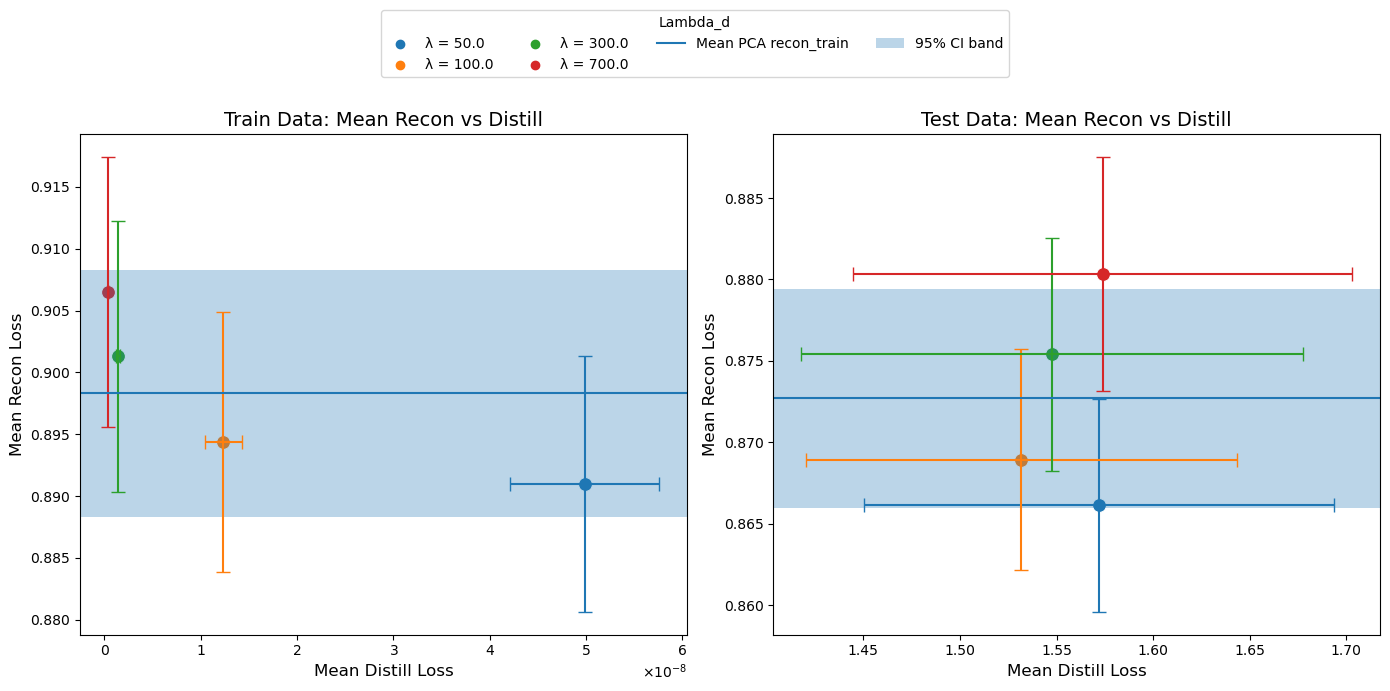

In [17]:
df_single_cell = pd.read_csv('results/single_cell_umap_drd_joint_n=801.csv')
df_single_cell = df_single_cell[df_single_cell.student_method == "drd"]
# Prepare the figure with two subplots: train and test
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False, sharey=False)

for idx, split in enumerate(['train', 'test']):
    ax = axes[idx]
    
    # Compute mean and SEM across seeds for each lambda_d
    grouped = df_single_cell.groupby('lambda_d').agg(
        mean_distill=('distill_' + split, 'mean'),
        sem_distill=(f'distill_{split}', 'sem'),
        mean_recon=('recon_' + split, 'mean'),
        sem_recon=('recon_' + split, 'sem')
    ).reset_index()
    
    # Create a color palette
    palette = sns.color_palette("tab10", n_colors=len(grouped))
    
    # Plot each point with error bars
    for i, row in grouped.iterrows():
        sns.scatterplot(x=[row['mean_distill']], y=[row['mean_recon']],hue=[row['lambda_d']],
            palette=[palette[i]], legend=False, s=100,ax=ax)
        ax.errorbar(row['mean_distill'], row['mean_recon'],yerr=row['sem_recon'], 
                    xerr=row['sem_distill'], fmt='none', ecolor=palette[i], capsize=5)
    
    if split == "train": 
        ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    # Set labels and title
    ax.set_xlabel('Mean Distill Loss', fontsize=12)
    ax.set_ylabel('Mean Recon Loss', fontsize=12)
    ax.set_title(f'{split.title()} Data: Mean Recon vs Distill', fontsize=14)
    
    # Create a custom legend
    for i, lam in enumerate(grouped['lambda_d']):
        ax.scatter([], [], color=palette[i], label=f'λ = {lam}')
    plot_pca_recon(df_single_cell, ax, split)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Lambda_d', ncol=4, loc='lower center', bbox_to_anchor=(0.5, 1.02),)
plt.tight_layout()
plt.show()


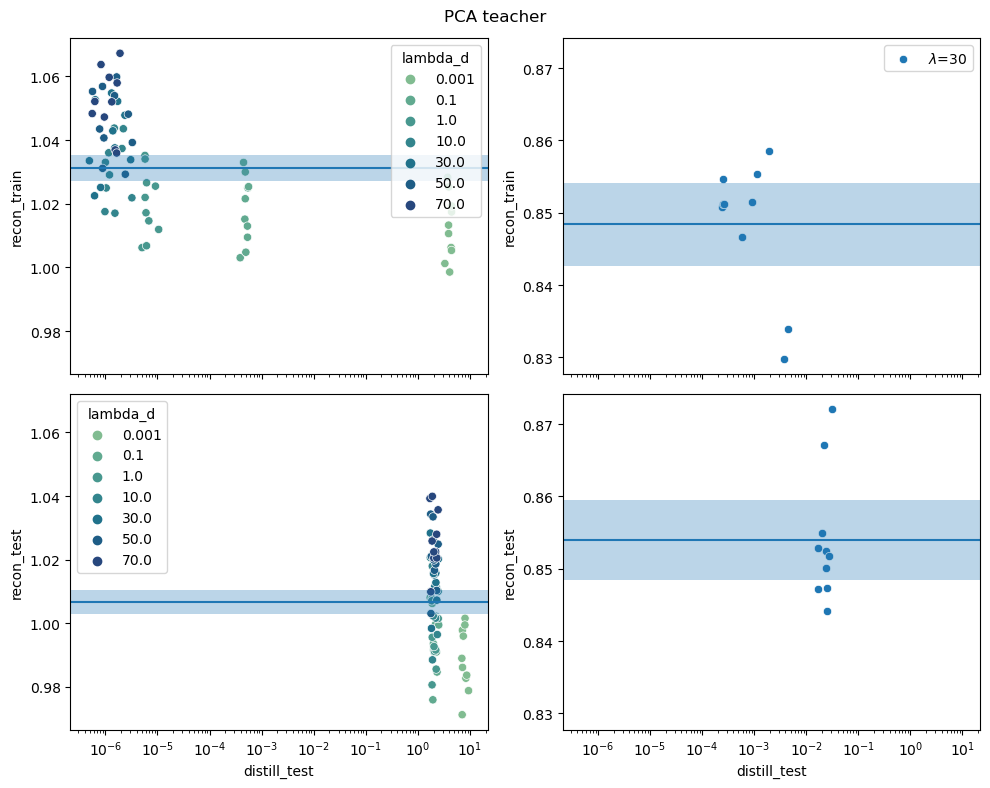

In [5]:
# plotting 
fig, axes = plt.subplots(2, 2, figsize=(10,8), sharex = True, sharey='col')
df_single_cell = pd.read_csv('results/single_cell_pca_drd_joint_p_0.5p_0.1p.csv')
df_single_cell = df_single_cell[df_single_cell.student_method == "drd"].copy()
sns.scatterplot(data = df_single_cell, x = 'distill_train', y = 'recon_train', marker='o', ax = axes[0, 0], palette=sns.color_palette("crest", 7), hue='lambda_d')
axes[0, 0].set_xscale('log')
axes[0, 0].set_xlabel('log(distill_train)')
plot_pca_recon(df_single_cell, axes[0, 0], "train")

df_mnist = pd.read_csv('results/mnist_pca_drd_joint_p_0.5p_0.1p.csv')
df_mnist = df_mnist[df_mnist.student_method == "drd"].copy()
sns.scatterplot(data = df_mnist, x = 'distill_train', y = 'recon_train', marker='o', ax = axes[0, 1], label='$\lambda$=30')
plt.xscale('log')
axes[0, 1].set_xlabel('log(distill_train)')
plot_pca_recon(df_mnist, axes[0, 1], "train")

sns.scatterplot(data = df_single_cell, x = 'distill_test', y = 'recon_test', marker='o', ax = axes[1, 0], palette=sns.color_palette("crest", 7), hue='lambda_d')
axes[1, 0].set_xlabel('distill_test')
plot_pca_recon(df_single_cell, axes[1, 0], "test")

sns.scatterplot(data = df_mnist, x = 'distill_test', y = 'recon_test', marker='o', ax = axes[1, 1])
axes[1, 1].set_xlabel('distill_test')
plot_pca_recon(df_mnist, axes[1, 1], "test")

plt.suptitle("PCA teacher")
plt.tight_layout()

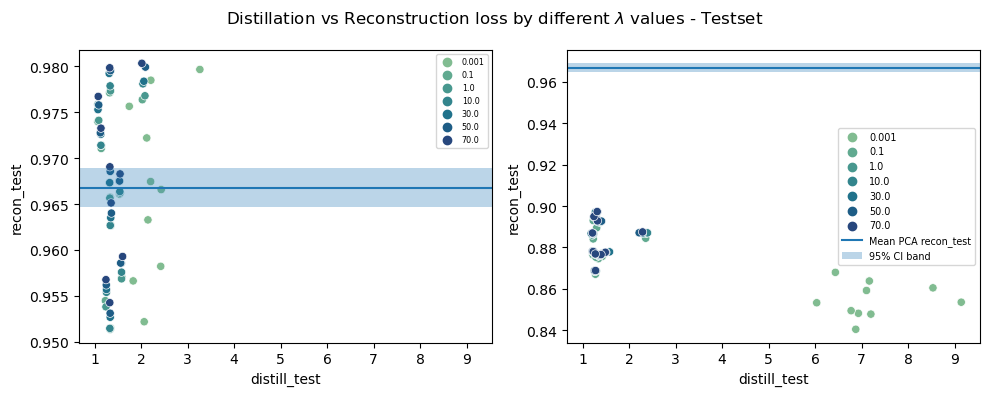

In [ ]:
# plotting 
fig, axes = plt.subplots(1, 2, figsize=(10,4), sharex = True)
df_single_cell = pd.read_csv('results/single_cell_umap_drd_joint_p_0.5p_0.1p.csv')
df_single_cell = df_single_cell[df_single_cell.teacher_method != "pca"]
df_single_cell = df_single_cell[df_single_cell.student_method == "drd"].copy()
sns.scatterplot(data = df_single_cell, x = 'distill_test', y = 'recon_test', marker='o', hue='lambda_d', ax = axes[0], palette=sns.color_palette("crest", 7))
# axes[0].set_xscale('log')
axes[0].set_xlabel('distill_test')
axes[0].legend(fontsize='xx-small')

sc_pca_recon_vals = df_single_cell.loc[df_single_cell.student_method == "drd", "recon_test"]
sc_pca_mean = sc_pca_recon_vals.mean()
sem = sc_pca_recon_vals.std(ddof=1) / np.sqrt(len(sc_pca_recon_vals))
ci = 1.96 * sem
axes[0].axhline(sc_pca_mean, label='Mean PCA recon_test')
axes[0].axhspan(sc_pca_mean - ci, sc_pca_mean + ci, alpha=0.3, label='95% CI band')

df_mnist = pd.read_csv('results/mnist_umap_drd_joint_p_0.5p_0.1p.csv')
df_mnist = df_mnist[df_mnist.teacher_method != "pca"]
df_mnist = df_mnist[df_mnist.student_method == "drd"].copy()
sns.scatterplot(data = df_mnist, x = 'distill_test', y = 'recon_test', marker='o', hue='lambda_d', ax = axes[1], palette=sns.color_palette("crest", 7))
# plt.xscale('log')
axes[1].set_xlabel('distill_test')
axes[1].legend(fontsize='xx-small')

mn_pca_recon_vals = df_single_cell.loc[df_single_cell.student_method == "drd", "recon_test"]
mn_pca_mean = mn_pca_recon_vals.mean()
sem = mn_pca_recon_vals.std(ddof=1) / np.sqrt(len(mn_pca_recon_vals))
ci = 1.96 * sem
axes[1].axhline(mn_pca_mean, label='Mean PCA recon_test')
axes[1].axhspan(mn_pca_mean - ci, mn_pca_mean + ci, alpha=0.3, label='95% CI band')
axes[1].legend(fontsize='x-small')

plt.suptitle("Distillation vs Reconstruction loss by different $\lambda$ values - Testset")
plt.tight_layout()

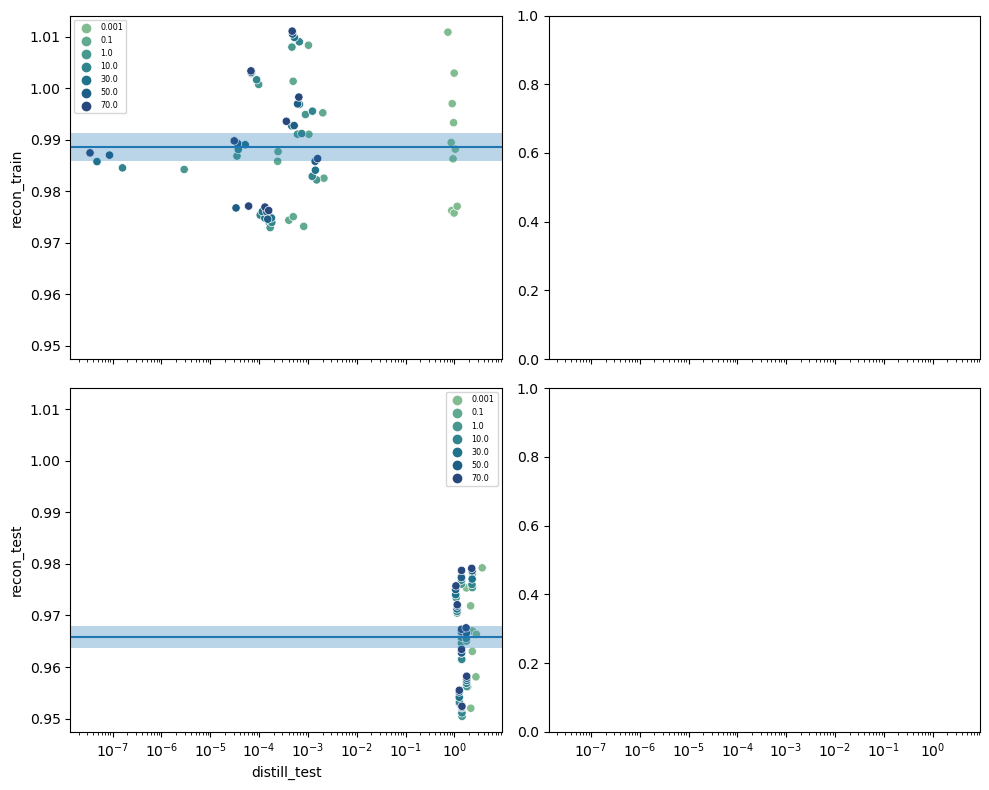

In [7]:
# plotting for 0.5p_0.1p_p
fig, axes = plt.subplots(2, 2, figsize=(10,8), sharex = True, sharey='col')
df_single_cell = pd.read_csv('results/single_cell_umap_drd_joint_0.5p_0.1p_p.csv')
df_single_cell = df_single_cell[df_single_cell.student_method == "drd"].copy()
sns.scatterplot(data = df_single_cell, x = 'distill_train', y = 'recon_train', marker='o', ax = axes[0, 0], hue='lambda_d', palette=sns.color_palette("crest", 7))
axes[0, 0].set_xscale('log')
axes[0, 0].set_xlabel('log(distill_train)')
axes[0, 0].legend(fontsize='xx-small')
plot_pca_recon(df_single_cell, axes[0, 0], "train")

# df_mnist = pd.read_csv('results/mnist_umap_drd_joint_0.5p_0.1p_p.csv')
# df_mnist = df_mnist[df_mnist.student_method == "drd"].copy()
# sns.scatterplot(data = df_mnist, x = 'distill_train', y = 'recon_train', marker='o', ax = axes[0, 1], label='$\lambda$=30')
# plt.xscale('log')
# axes[0, 1].set_xlabel('log(distill_train)')
# plot_pca_recon(df_mnist, axes[0, 1], "train")

sns.scatterplot(data = df_single_cell, x = 'distill_test', y = 'recon_test', marker='o', ax = axes[1, 0], hue='lambda_d', palette=sns.color_palette("crest", 7))
axes[1, 0].set_xlabel('distill_test')
axes[1, 0].legend(fontsize='xx-small')
plot_pca_recon(df_single_cell, axes[1, 0], "test")

# sns.scatterplot(data = df_mnist, x = 'distill_test', y = 'recon_test', marker='o', ax = axes[1, 1])
# axes[1, 1].set_xlabel('distill_test')
# plot_pca_recon(df_mnist, axes[1, 1], "test")

plt.tight_layout()